In [1]:
import sys, os
sys.path.append(os.path.abspath(".."))
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from preprocessing.preprocessing_utils import nn_preprocess

# Set random seed for reproducibility (Crucial for a "Reference" implementation)
torch.manual_seed(7)
np.random.seed(7)

print("Libraries loaded. PyTorch version:", torch.__version__)

Libraries loaded. PyTorch version: 2.9.1+cpu


In [2]:
# 1. Load Data
train = pd.read_csv("../data/claims_train.csv")
test  = pd.read_csv("../data/claims_test.csv")

# 2. Preprocess Training Data
# We pass scaler=None so it fits a new scaler
X_train_df, y_train_s, w_train_s, scaler = nn_preprocess(train, scaler=None, ref_columns=None)
train_cols = X_train_df.columns.tolist()

# Process Test Data
X_test_df, y_test_s, w_test_s, _ = nn_preprocess(test, scaler=scaler, ref_columns=train_cols)

# Convert to Numpy (float32)
X_train = X_train_df.values.astype(np.float32)
y_train = y_train_s.values.astype(np.float32).reshape(-1, 1)
w_train = w_train_s.values.astype(np.float32).reshape(-1, 1)

X_test = X_test_df.values.astype(np.float32)
y_test = y_test_s.values.astype(np.float32).reshape(-1, 1)
w_test = w_test_s.values.astype(np.float32).reshape(-1, 1)

# Convert to PyTorch Tensors
X_train_tensor = torch.tensor(X_train)
y_train_tensor = torch.tensor(y_train)
# We might need exposure tensor for loss calculation
w_train_tensor = torch.tensor(w_train)

X_test_tensor = torch.tensor(X_test)
y_test_tensor = torch.tensor(y_test)
w_test_tensor = torch.tensor(w_test)

print(f"Features: {X_train.shape[1]}")
print(f"Train samples: {X_train.shape[0]}")
print(f"Test samples: {X_test.shape[0]}")

Features: 126
Train samples: 542410
Test samples: 135603


In [3]:
class DynamicNN(nn.Module):
    def __init__(self, input_dim, hidden_layers):
        super(DynamicNN, self).__init__()
        self.layers = nn.ModuleList()
        current_dim = input_dim
        
        for hidden_dim in hidden_layers:
            self.layers.append(nn.Linear(current_dim, hidden_dim))
            self.layers.append(nn.ReLU())
            current_dim = hidden_dim
            
        self.output_layer = nn.Linear(current_dim, 1)

    def forward(self, x):
        for layer in self.layers:
            x = layer(x)
        # Force positive output for Poisson Rate using Exp
        x = self.output_layer(x)
        return torch.exp(x)

def poisson_deviance_loss(y_pred, y_true, weight):
    """
    2 * w * (y_true * log(y_true / y_pred) - (y_true - y_pred))
    """
    epsilon = 1e-8
    y_pred = torch.clamp(y_pred, min=epsilon)
    
    term1 = torch.zeros_like(y_true)
    mask = y_true > 0
    # Only calculate log where y_true > 0 to avoid log(0) error
    term1[mask] = y_true[mask] * torch.log(y_true[mask] / y_pred[mask])
    
    term2 = y_true - y_pred
    
    deviance = 2 * weight * (term1 - term2)
    return torch.mean(deviance)

def sklearn_poisson_deviance(y_true, y_pred, weight):
    """
    Manual implementation of sklearn.metrics.mean_poisson_deviance
    Formula: 2 * w * (y * log(y / y_pred) - (y - y_pred))
    """
    # Convert to numpy if tensors
    if isinstance(y_true, torch.Tensor): y_true = y_true.numpy()
    if isinstance(y_pred, torch.Tensor): y_pred = y_pred.detach().numpy()
    if isinstance(weight, torch.Tensor): weight = weight.numpy()
    
    # Ensure no zeros in prediction to avoid divide-by-zero
    y_pred = np.clip(y_pred, 1e-10, None)
    
    # Term 1: y * log(y / y_pred)
    # Note: If y=0, then y*log(...) is 0.
    term1 = np.zeros_like(y_true)
    mask = y_true > 0
    term1[mask] = y_true[mask] * np.log(y_true[mask] / y_pred[mask])
    
    # Term 2: -(y - y_pred)
    term2 = -(y_true - y_pred)
    
    # Final Deviance
    dev_per_sample = 2 * weight * (term1 + term2)
    
    return np.sum(dev_per_sample) / np.sum(weight)

In [4]:
def run_experiment(config, lr, weight_decay, epochs=50, batch_size=1024, verbose=True):
    """
    Trains model and returns Test Deviance.
    Batch size increased to 1024 for speed.
    """
    input_dim = X_train_tensor.shape[1]
    model = DynamicNN(input_dim, config)
    
    # Using SGD to mimic future "from scratch" implementation
    # Reduced momentum/nesterov to keep it simple for scratch comparison
    optimizer = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)
    
    model.train()
    
    # Pre-calculate number of batches
    n_samples = X_train_tensor.size(0)
    
    for epoch in range(epochs):
        permutation = torch.randperm(n_samples)
        
        for i in range(0, n_samples, batch_size):
            indices = permutation[i:i+batch_size]
            
            batch_x = X_train_tensor[indices]
            batch_y = y_train_tensor[indices]
            batch_w = w_train_tensor[indices] # Exposure weights

            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = poisson_deviance_loss(outputs, batch_y, batch_w)
            loss.backward()
            optimizer.step()
            
        if verbose and (epoch+1) % 5 == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {loss.item():.5f}")

    # Evaluate
    model.eval()
    with torch.no_grad():
        pred_test = model(X_test_tensor)
        test_loss = poisson_deviance_loss(pred_test, y_test_tensor, w_test_tensor)
        
    return test_loss.item()

In [ ]:
architectures = [
    [16, 8],
    [32],           
    [64],          
    [128],
    [256],        
    [64, 32],       
    [128, 64],      
    [64, 32, 16],
    [128, 64, 32]
]

fixed_lr = 0.0001 
fixed_reg = 0.0

print(f"{'Architecture':<20} | {'Test Deviance':<15}")
print("-" * 40)

arch_results = {}

for arch in architectures:
    deviance = run_experiment(config=arch, lr=fixed_lr, weight_decay=fixed_reg, epochs=50, batch_size=1024, verbose=False)
    arch_results[str(arch)] = deviance
    print(f"{str(arch):<20} | {deviance:.5f}")

# Automatically select winner
best_arch_str = min(arch_results, key=arch_results.get)
best_arch = eval(best_arch_str)
print("-" * 40)
print(f"Winner Architecture: {best_arch}")

Architecture         | Test Deviance  
----------------------------------------
[16, 8]              | 0.37095
[32]                 | 0.37914
[64]                 | 0.35360
[128]                | 0.34956
[64, 32]             | 0.36683
[128, 64]            | 0.37600
[64, 32, 16]         | 0.38550
[128, 64, 32]        | 0.35881
----------------------------------------
Winner Architecture: [128]


In [6]:
learning_rates = [0.1, 0.05, 0.01, 0.005, 0.001] 
regularizations = [0, 0.0001, 0.001]

print(f"Tuning for Architecture: {best_arch}")
print(f"{'LR':<8} | {'Reg':<8} | {'Test Deviance':<15}")
print("-" * 40)

best_loss = float('inf')
best_params = {}

for lr in learning_rates:
    for reg in regularizations:
        deviance = run_experiment(config=best_arch, lr=lr, weight_decay=reg, epochs=50, batch_size=1024, verbose=False)
        
        print(f"{lr:<8} | {reg:<8} | {deviance:.5f}")
        
        if deviance < best_loss:
            best_loss = deviance
            best_params = {'lr': lr, 'reg': reg}

print("-" * 40)
print(f"Best Params: {best_params} with Deviance: {best_loss:.5f}")

Tuning for Architecture: [128]
LR       | Reg      | Test Deviance  
----------------------------------------
0.01     | 0        | 0.32170
0.01     | 0.0001   | 0.32179
0.01     | 0.001    | 0.32198
0.005    | 0        | 0.32302
0.005    | 0.0001   | 0.32298
0.005    | 0.001    | 0.32336
0.001    | 0        | 0.32633
0.001    | 0.0001   | 0.32629
0.001    | 0.001    | 0.32614
----------------------------------------
Best Params: {'lr': 0.01, 'reg': 0} with Deviance: 0.32170


In [7]:
def plot_lorenz_curve(y_true, y_pred, exposure):
    """
    Plots Lorenz Curve for Gini Coefficient calculation.
    """
    order = np.argsort(y_pred, axis=0)[::-1].flatten()
    y_true_sorted = y_true[order]
    exposure_sorted = exposure[order]
    
    cum_exposure = np.cumsum(exposure_sorted)
    cum_exposure /= cum_exposure[-1] 
    
    cum_claims = np.cumsum(y_true_sorted * exposure_sorted)
    cum_claims /= cum_claims[-1]
    
    auc = np.trapz(cum_claims.flatten(), cum_exposure.flatten())
    gini = (auc - 0.5) / 0.5
    
    plt.figure(figsize=(6, 6))
    plt.plot(cum_exposure, cum_claims, label=f'Model (Gini: {gini:.3f})')
    plt.plot([0, 1], [0, 1], 'k--', label='Random')
    plt.title("Lorenz Curve (Ordered by Predicted Risk)")
    plt.xlabel("Cumulative Exposure")
    plt.ylabel("Cumulative Claims")
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return gini

def plot_calibration(y_true, y_pred, exposure, n_bins=10):
    """
    Compares Predicted Risk vs Actual Risk in bins (Absolute scale).
    """
    df_res = pd.DataFrame({
        'Observed': y_true.flatten(),
        'Predicted': y_pred.flatten(),
        'Exposure': exposure.flatten()
    })
    
    df_res['Bin'] = pd.qcut(df_res['Predicted'], n_bins, duplicates='drop')
    
    grouped = df_res.groupby('Bin', observed=False).apply(
        lambda x: pd.Series({
            'Mean_Pred': np.average(x['Predicted'], weights=x['Exposure']),
            'Mean_Obs': np.average(x['Observed'], weights=x['Exposure'])
        })
    )
    
    plt.figure(figsize=(10, 5))
    x = np.arange(len(grouped))
    width = 0.35
    
    plt.bar(x - width/2, grouped['Mean_Pred'], width, label='Predicted')
    plt.bar(x + width/2, grouped['Mean_Obs'], width, label='Observed')
    
    plt.xlabel('Risk Deciles (Low to High)')
    plt.ylabel('Claim Frequency')
    plt.title('Model Calibration (Absolute Frequencies)')
    plt.xticks(x, labels=[f"{i+1}" for i in x])
    plt.legend()
    plt.grid(True, axis='y', alpha=0.5)
    plt.show()
    
    print("\nCalibration Table:")
    print(grouped)

def plot_lift_chart(y_true, y_pred, exposure, n_bins=10):
    """
    Plots the Lift Chart (Ratio of Bin Frequency to Global Average Frequency).
    Shows how much better the model is at separating risk compared to the average.
    """
    # 1. Calculate Global Average Frequency (Portfolio Mean)
    global_mean = np.average(y_true, weights=exposure)
    
    df_res = pd.DataFrame({
        'Observed': y_true.flatten(),
        'Predicted': y_pred.flatten(),
        'Exposure': exposure.flatten()
    })
    
    # 2. Bin by Predicted Risk
    df_res['Bin'] = pd.qcut(df_res['Predicted'], n_bins, duplicates='drop')
    
    # 3. Calculate Weighted Means per Bin
    grouped = df_res.groupby('Bin', observed=False).apply(
        lambda x: pd.Series({
            'Mean_Pred': np.average(x['Predicted'], weights=x['Exposure']),
            'Mean_Obs': np.average(x['Observed'], weights=x['Exposure'])
        })
    )
    
    # 4. Calculate Lift (Bin Mean / Global Mean)
    # Example: Lift=1.5 means this segment is 50% riskier than average
    grouped['Lift_Pred'] = grouped['Mean_Pred'] / global_mean
    grouped['Lift_Obs'] = grouped['Mean_Obs'] / global_mean
    
    # 5. Plot
    plt.figure(figsize=(10, 5))
    x = np.arange(len(grouped))
    
    plt.plot(x, grouped['Lift_Pred'], marker='o', label='Predicted Lift', linestyle='-', linewidth=2)
    plt.plot(x, grouped['Lift_Obs'], marker='x', label='Observed Lift', linestyle='--', linewidth=2)
    plt.axhline(1.0, color='gray', linestyle=':', label='Average (1.0)')
    
    plt.xlabel('Risk Deciles (Low to High)')
    plt.ylabel('Lift (Relative to Average)')
    plt.title(f'Lift Chart (Global Frequency: {global_mean:.4f})')
    plt.xticks(x, labels=[f"{i+1}" for i in x])
    plt.legend()
    plt.grid(True, alpha=0.5)
    plt.show()
    
    print("\nLift Table (Ratio to Average):")
    print(grouped[['Lift_Pred', 'Lift_Obs']])

In [8]:
final_lr = best_params['lr']
final_reg = best_params['reg']

print(f"\nTraining Final Model ({best_arch}) with LR={final_lr}, Reg={final_reg}...")

model = DynamicNN(X_train_tensor.shape[1], best_arch)
optimizer = optim.SGD(model.parameters(), lr=final_lr, weight_decay=final_reg)

final_epochs = 150
loss_history = []

model.train()
n_samples = X_train_tensor.size(0)
batch_size = 1024

for epoch in range(final_epochs):
    permutation = torch.randperm(n_samples)
    epoch_loss = 0
    
    for i in range(0, n_samples, batch_size):
        indices = permutation[i:i+batch_size]
        batch_x = X_train_tensor[indices]
        batch_y = y_train_tensor[indices]
        batch_w = w_train_tensor[indices]
        
        optimizer.zero_grad()
        outputs = model(batch_x)
        loss = poisson_deviance_loss(outputs, batch_y, batch_w)
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item() * len(indices)

    avg_loss = epoch_loss / n_samples
    loss_history.append(avg_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}: Train Deviance {avg_loss:.5f}")



Training Final Model ([128]) with LR=0.01, Reg=0...
Epoch 10: Train Deviance 0.32186
Epoch 20: Train Deviance 0.32054
Epoch 30: Train Deviance 0.31971
Epoch 40: Train Deviance 0.31906
Epoch 50: Train Deviance 0.31847
Epoch 60: Train Deviance 0.31792
Epoch 70: Train Deviance 0.31735
Epoch 80: Train Deviance 0.31677
Epoch 90: Train Deviance 0.31616
Epoch 100: Train Deviance 0.31554
Epoch 110: Train Deviance 0.31489
Epoch 120: Train Deviance 0.31423
Epoch 130: Train Deviance 0.31357
Epoch 140: Train Deviance 0.31292
Epoch 150: Train Deviance 0.31228



=== TRUE M2 PERFORMANCE ===
Mean Poisson Deviance: 0.59791
D^2 Score: 5.55%

--- Evaluation Metrics ---


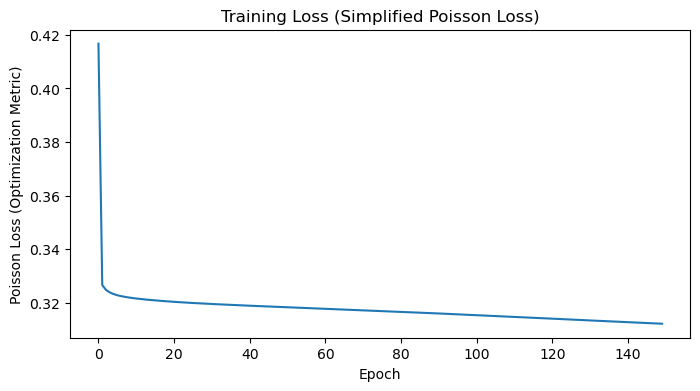

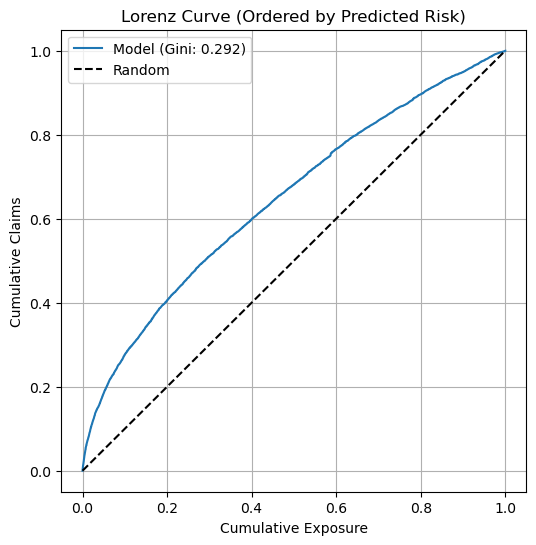

Gini Coefficient: 0.2919


C:\Users\Emil\AppData\Local\Temp\ipykernel_9940\738723542.py:42: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grouped = df_res.groupby('Bin', observed=False).apply(


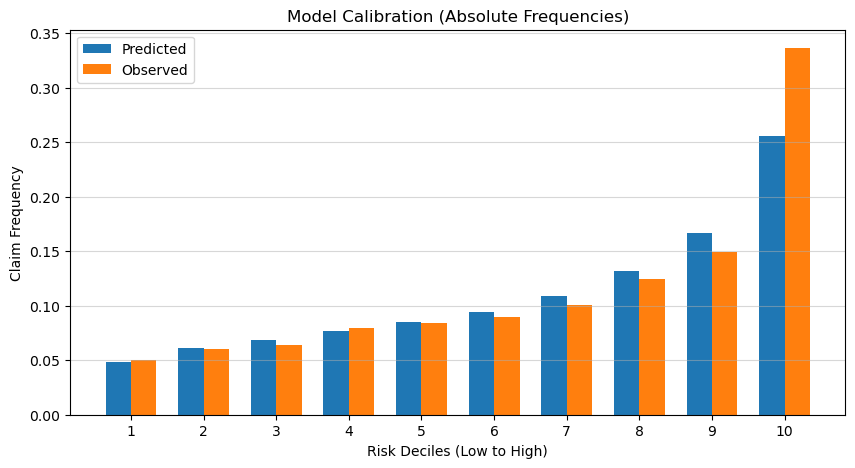


Calibration Table:
                  Mean_Pred  Mean_Obs
Bin                                  
(0.0178, 0.0563]   0.048506  0.049989
(0.0563, 0.0652]   0.060897  0.060438
(0.0652, 0.0728]   0.068987  0.063666
(0.0728, 0.0805]   0.076613  0.079231
(0.0805, 0.0891]   0.084667  0.084340
(0.0891, 0.101]    0.094379  0.089334
(0.101, 0.119]     0.109179  0.100952
(0.119, 0.146]     0.131968  0.124112
(0.146, 0.193]     0.166552  0.149400
(0.193, 0.695]     0.255668  0.336510


In [9]:
# --- Generate Plots ---
model.eval()
with torch.no_grad():
    y_pred_test = model(X_test_tensor).numpy()
    y_true_test = y_test_tensor.numpy()
    w_test_numpy = w_test_tensor.numpy()

final_m2_deviance = sklearn_poisson_deviance(y_true_test, y_pred_test, w_test_numpy)

# Calculate D^2
# We need the Null Deviance (baseline)
global_mean_freq = np.average(y_true_test, weights=w_test_numpy)
y_null = np.full_like(y_true_test, global_mean_freq)
null_deviance = sklearn_poisson_deviance(y_true_test, y_null, w_test_numpy)

d2_score = 1 - (final_m2_deviance / null_deviance)

print(f"\n=== TRUE M2 PERFORMANCE ===")
print(f"Mean Poisson Deviance: {final_m2_deviance:.5f}")
print(f"D^2 Score: {d2_score:.2%}")

print("\n--- Evaluation Metrics ---")

# 1. Loss Curve
plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.title("Training Loss (Simplified Poisson Loss)")
plt.xlabel("Epoch")
plt.ylabel("Poisson Loss (Optimization Metric)")
plt.show()

# 2. Lorenz Curve & Gini
gini_score = plot_lorenz_curve(y_true_test, y_pred_test, w_test_numpy)
print(f"Gini Coefficient: {gini_score:.4f}")

# 3. Calibration
plot_calibration(y_true_test, y_pred_test, w_test_numpy)

# 4. Lift Chart
#plot_lift_chart(y_true_test, y_pred_test, w_test_numpy)